#### t-SNE
- 비선형 차원축소 기법으로 고차원의 데이터를 국소 구조를 2차원 또는 3차원 시각화를 하기 위해 사용
- 고차원 데이터의 경우에는 거리 기반 유사도(가우시안 분포를 이용한 계산)
- 저차원의 경우에는 확률적으로 비슷하게 재현(t-분포를 이용한 계산)
    - t-분포를 사용하는 이유는 멀리 떨어진 점간의 거리 차이를 완화시키기 위한 방법

- 거리 계산 방법
    - 유클리드 거리(euclidean) -> 기본적인 거리 방식 (직선의 거리)
    - 맨헤튼 거리(manhattan) -> 직각 축 기반 거리
    - 체비표스 거리(chebyshev) -> 최대의 축 차이 기반
    - 코사인 거리(유사도)(cosine) -> 벡터 방향 기반 -> 자연어 데이터에서 사용
    - 마할라노비스 거리(mahalanobis) -> 변수 간 상관 반영

- parameter
    - n_components
        - 기본값 : 2
        - 축소할 차원의 개수
    - perplexity
        - 기본값 : 30
        - 이웃의 주 제어(군집 크기 민감)
        - 보통 5 ~ 50 정도의 값을 사용
        - 값이 작은 경우 작은 구조, 큰 경우 전체의 구조
        - 일반적으로 샘플의 개수 / 3
        - 너무 큰 값을 설정하면 전체를 포괄하는 형태가 될 수 있다
    - early_exggerarion
        - 기본값 : 12
        - 초기 학습에서 군집 간의 거리를 지정(분리 촉진)
    - learning_rate
        - 기본값: 'auto'
        - 학습의 속도
        - 너무 작게 지정하면 수렴이 느려짐
        - 너무 크게 지정하면 군집이 왜곡
        - 100 ~ 1000 정도 값을 사용
    - max_iter
        - 기본값 : 1000
        - 전체 학습의 반복 횟수
    - n_iter_without_progress
        - 기본값 : 300
        - 개선이 없을 때 조기 종료의 기준
    - metric
        - 기본값 : 'euclidean'
        - 거리 계산 방식
- 속성
    - embedding_
        - 변환된 저차원 데이터를 반환
    - kl_divergence_
        - 최종 KL 발산 값을 반환(쟉을수록 원래의 구조와 유사)
- 메서드
    - fit()
        - 데이터를 학습
    - transform()
        - 데이터를 저차원으로 변환

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [12]:
# digits 데이터를 로드
digits = load_digits()

In [13]:
len(digits.feature_names)

64

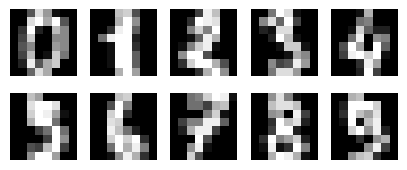

In [14]:
plt.figure(figsize=(5,2))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap = 'gray')
    # plt.title('label : ', digits.target[i])
    plt.axis('off')
plt.show()

In [15]:
import pandas as pd

In [16]:
pd.DataFrame(digits.data)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [17]:
# 64차원 데이터를 2차원으로 변경
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42,
    n_jobs=-1,
    
)

In [18]:
x = StandardScaler().fit_transform(digits['data'])
y = digits['target']

In [19]:
x_tsne = tsne.fit_transform(x)

In [20]:
print(x.shape)
print(x_tsne.shape)

(1797, 64)
(1797, 2)


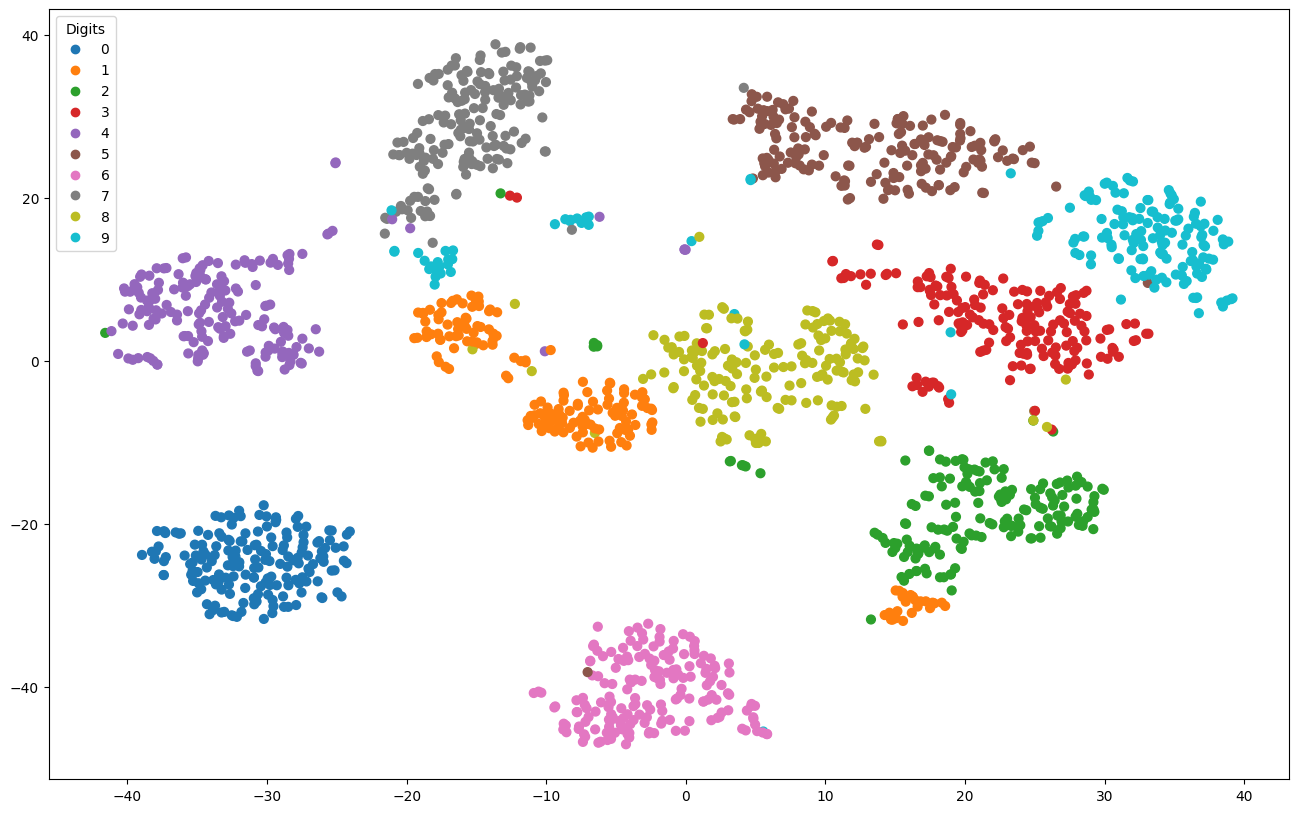

In [21]:
# 2차원으로 축소된 그래프를 산점도 그래프로 표시
plt.figure(figsize=(16,10))

sc = plt.scatter(
    x_tsne[:,0], x_tsne[:,1], c = y, cmap='tab10', s=40
)

plt.legend(*sc.legend_elements(), title = 'Digits')

plt.show()

In [22]:
from sklearn.decomposition import PCA

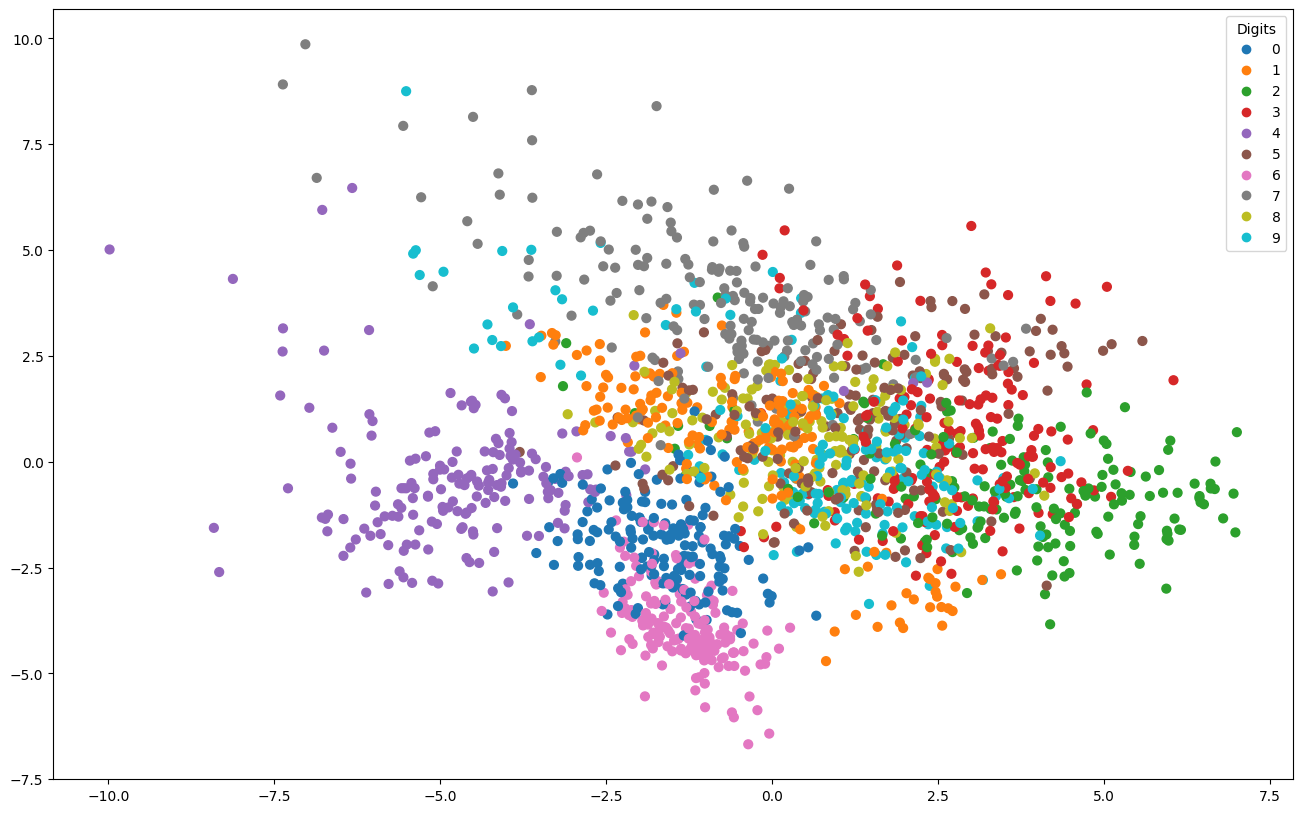

In [23]:
pca = PCA(n_components=2, random_state=42)

x_pca = pca.fit_transform(x)

plt.figure(figsize=(16,10))

sc = plt.scatter(
    x_pca[:,0], x_pca[:,1], c = y, cmap='tab10', s=40
)

plt.legend(*sc.legend_elements(), title = 'Digits')

plt.show()